In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
from Univariate import Univariate

dataset = pd.read_csv("cleaned_ckd_dataset.csv")

quan, qual = Univariate.quanQual(dataset)

dataset.isnull().sum()

id                0
age               0
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
pcv               0
wc                0
rc                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64

In [2]:
descriptive, lesser_outliers, greater_outliers = Univariate.descriptive(dataset,quan)

In [3]:
descriptive

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc
Mean,201.083636,51.6,76.180364,1.016564,0.912727,0.385455,151.268727,57.468,3.047273,137.185091,4.770545,12.487273,38.981818,8352.794182,4.686182
Median,199.0,54.0,76.2,1.015,0.0,0.0,130.0,44.0,1.4,137.2,4.7,12.5,39.0,8352.8,4.7
Mode,1,65.0,80.0,1.01,0.0,0.0,151.3,57.5,1.2,137.2,4.8,12.5,39.0,8352.8,4.7
Q1:25%,108.0,42.0,70.0,1.01,0.0,0.0,103.5,28.0,0.95,135.0,4.0,10.9,34.0,6900.0,4.5
Q2:50%,199.0,54.0,76.2,1.015,0.0,0.0,130.0,44.0,1.4,137.2,4.7,12.5,39.0,8352.8,4.7
Q3:75%,300.5,65.0,80.0,1.02,2.0,0.0,162.5,60.5,3.0,140.0,4.8,14.4,44.0,9250.0,5.0
99%,394.04,80.26,112.6,1.025,4.0,4.0,430.72,258.68,19.56,150.0,6.426,17.626,52.26,17272.0,6.426
Q4:100%,399.0,90.0,180.0,1.025,5.0,5.0,490.0,391.0,76.0,163.0,47.0,17.8,54.0,26400.0,8.0
IQR,192.5,23.0,10.0,0.01,2.0,0.0,59.0,32.5,2.05,5.0,0.8,3.5,10.0,2350.0,0.5
1.5RULE,288.75,34.5,15.0,0.015,3.0,0.0,88.5,48.75,3.075,7.5,1.2,5.25,15.0,3525.0,0.75


In [4]:
lesser_outliers

['age', 'bp', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']

In [5]:
greater_outliers

['bp', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'wc', 'rc']

Mean=12.487, Standard deviation=2.677


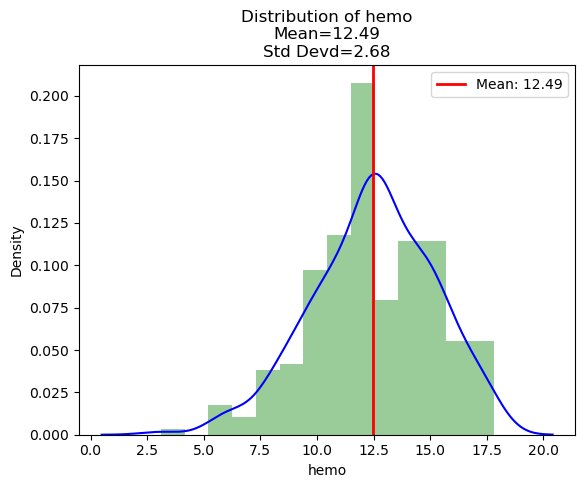

In [6]:
Univariate.get_distribution_plot(dataset['hemo'],'hemo')

In [7]:
for column in lesser_outliers:
    dataset[column][dataset[column] < descriptive[column]['LesserOutlier']] = descriptive[column]['LesserOutlier']

for column in greater_outliers:
    dataset[column][dataset[column] > descriptive[column]['GreaterOutlier']] = descriptive[column]['GreaterOutlier']

In [8]:
descriptive_new, lesser_outliers, greater_outliers = Univariate.descriptive(dataset,quan)

In [9]:
descriptive_new

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc
Mean,201.083636,51.656364,75.289455,1.016564,0.912727,0.0,143.839636,50.385273,2.219,137.806909,4.495273,12.496727,39.04,8178.794182,4.721455
Median,199.0,54.0,76.2,1.015,0.0,0.0,130.0,44.0,1.4,137.2,4.7,12.5,39.0,8352.8,4.7
Mode,1,65.0,80.0,1.01,0.0,0.0,151.3,109.25,6.075,137.2,4.8,12.5,39.0,8352.8,4.7
Q1:25%,108.0,42.0,70.0,1.01,0.0,0.0,103.5,28.0,0.95,135.0,4.0,10.9,34.0,6900.0,4.5
Q2:50%,199.0,54.0,76.2,1.015,0.0,0.0,130.0,44.0,1.4,137.2,4.7,12.5,39.0,8352.8,4.7
Q3:75%,300.5,65.0,80.0,1.02,2.0,0.0,162.5,60.5,3.0,140.0,4.8,14.4,44.0,9250.0,5.0
99%,394.04,80.26,95.0,1.025,4.0,0.0,251.0,109.25,6.075,147.5,6.0,17.626,52.26,12775.0,5.75
Q4:100%,399.0,90.0,95.0,1.025,5.0,0.0,251.0,109.25,6.075,147.5,6.0,17.8,54.0,12775.0,5.75
IQR,192.5,23.0,10.0,0.01,2.0,0.0,59.0,32.5,2.05,5.0,0.8,3.5,10.0,2350.0,0.5
1.5RULE,288.75,34.5,15.0,0.015,3.0,0.0,88.5,48.75,3.075,7.5,1.2,5.25,15.0,3525.0,0.75


Mean=12.497, Standard deviation=2.648


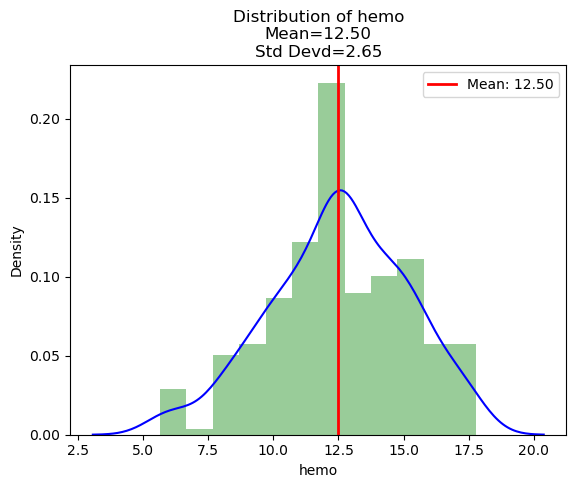

In [10]:
Univariate.get_distribution_plot(dataset['hemo'],'hemo')

# Probability Density Function (PDF)

#### Finding probability density for hemo = 10

In [14]:
from scipy.stats import norm
dist = norm(dataset['hemo'].mean(),dataset['hemo'].std())

pdf = dist.pdf(10)
pdf

np.float64(0.09659412249043049)

# Cummulative Distribution Function (CDF)

#### Finding probability of hemo ranging between 10 to 15

In [25]:
cdf = dist.cdf(15) - dist.cdf(10)
cdf

# 65% chances of hemo between 10 to 15

np.float64(0.6549307138650695)

# z-score Analysis & Standard Normal distribution

In [31]:
mean = dataset['hemo'].mean()
std = dataset['hemo'].std()

values = [i for i in dataset['hemo']]
z_scores = [((i-mean)/std) for i in values]
z_scores

[np.float64(0.03900392539792209),
 np.float64(-0.300907044179038),
 np.float64(-0.14983550214483346),
 np.float64(2.0029339718425803),
 np.float64(-0.5275143572303446),
 np.float64(0.0012360398893711154),
 np.float64(1.8896303153169265),
 np.float64(1.0587368341288024),
 np.float64(0.07677181090647306),
 np.float64(-2.3403728616407977),
 np.float64(0.45445066599198414),
 np.float64(-1.6983188079954288),
 np.float64(0.5299864370090868),
 np.float64(0.2656112384492286),
 np.float64(0.0012360398893711154),
 np.float64(0.0012360398893711154),
 np.float64(-1.094032639858611),
 np.float64(0.6432900935347398),
 np.float64(-0.2631391586704864),
 np.float64(0.4166827804834332),
 np.float64(-0.8296574412987531),
 np.float64(-0.5275143572303446),
 np.float64(0.9076652920945979),
 np.float64(-0.5275143572303446),
 np.float64(-1.6605509224868777),
 np.float64(1.6630230022656194),
 np.float64(-2.2270692051151446),
 np.float64(-0.9429610978244066),
 np.float64(0.0012360398893711154),
 np.float64(2.00

<Axes: ylabel='Density'>

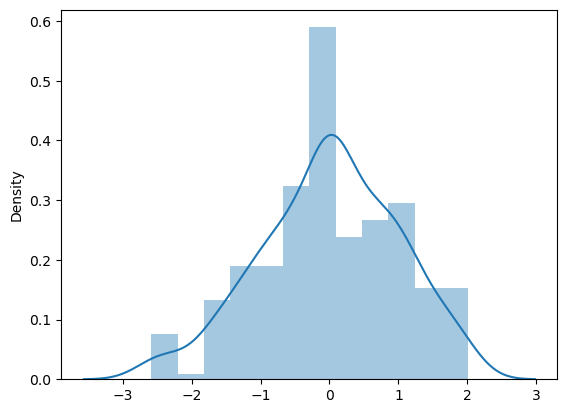

In [35]:
import seaborn as sns
sns.distplot(z_scores,kde=True)